In [84]:
import pandas as pd
import numpy as np

In [2]:

df = pd.read_csv("../data/dataset.csv")

print(df.head())

                                                text     category  language
0                         Bus bahut crowded thi aaj.       Travel  Hinglish
1  I need to hand over my tasks before I leave th...  Work/Office   English
2  Mere ilake ka traffic signal kharab hai hamesh...       Travel  Hinglish
3  Mujhe service ke baare mein ek general query h...      General  Hinglish
4   Meri request pe koi follow up nahi hua har baar.    Complaint  Hinglish


In [ ]:
df.info()

In [3]:
print(df.shape)


(1200, 3)


In [4]:
print(df["category"].value_counts())


category
Travel         200
Work/Office    200
General        200
Complaint      200
Health         200
Mood           200
Name: count, dtype: int64


In [5]:
print(df["language"].value_counts())

language
Hinglish    600
English     600
Name: count, dtype: int64


In [6]:
print("Duplicate texts:", df["text"].duplicated().sum())

Duplicate texts: 0


In [7]:
print(df.isnull().sum())

text        0
category    0
language    0
dtype: int64


In [8]:
print(
    pd.crosstab(
        df["category"],
        df["language"]
    )
)

language     English  Hinglish
category                      
Complaint        100       100
General          100       100
Health           100       100
Mood             100       100
Travel           100       100
Work/Office      100       100


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

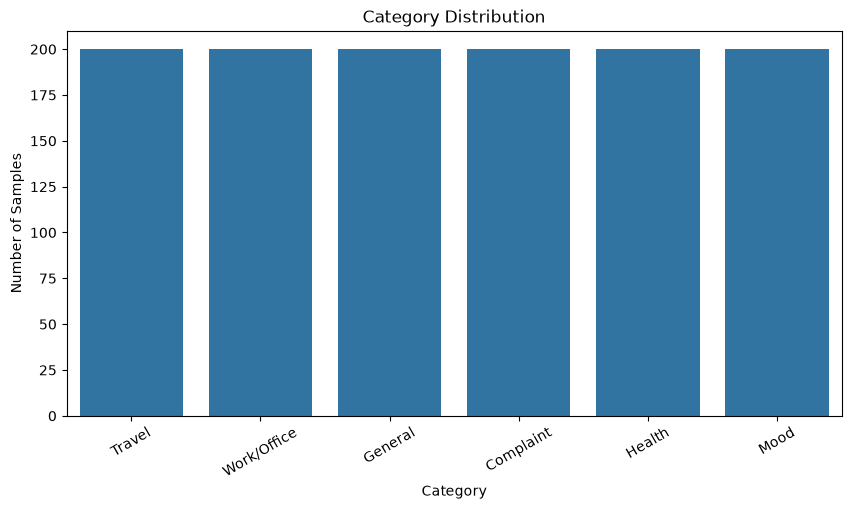

In [10]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="category",
    order=df["category"].value_counts().index
)

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)

plt.show()

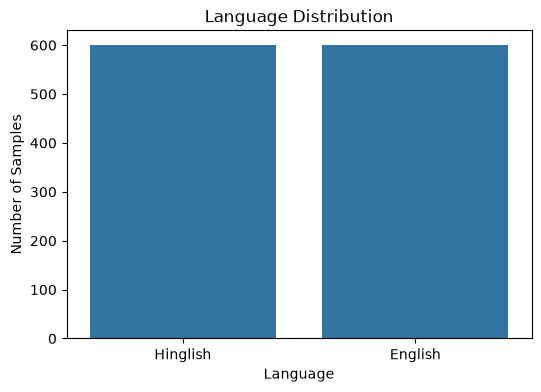

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="language"
)

plt.title("Language Distribution")
plt.xlabel("Language")
plt.ylabel("Number of Samples")

plt.show()

In [12]:
df.sample(20, random_state=42)

,text,category,language
1178,I have a client call scheduled today.,Work/Office,English
865,I'm planning a trip with friends this weekend.,Travel,English
101,Mujhe process ke baare mein thodi information ...,General,Hinglish
439,The instructions on the packaging were mislead...,Complaint,English
58,I love long road trips as usual.,Travel,English
1120,My flight got rescheduled because of the weath...,Travel,English
323,I am worried about how things will turn out to...,Mood,English
974,I'm planning to work from home later today.,Work/Office,English
411,Mera dil tuta hua hai in dino.,Mood,Hinglish
855,Meri poore din meetings hain aaj subah.,Work/Office,Hinglish


In [85]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [86]:
df["clean_text"] = df["text"].apply(clean_text)

In [87]:
df[["text", "clean_text"]].head()

,text,clean_text
0,Bus bahut crowded thi aaj.,bus bahut crowded thi aaj.
1,I need to hand over my tasks before I leave th...,i need to hand over my tasks before i leave th...
2,Mere ilake ka traffic signal kharab hai hamesh...,mere ilake ka traffic signal kharab hai hamesh...
3,Mujhe service ke baare mein ek general query h...,mujhe service ke baare mein ek general query h...
4,Meri request pe koi follow up nahi hua har baar.,meri request pe koi follow up nahi hua har baar.


In [88]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
import joblib
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [89]:
X = df["clean_text"]
y = df["category"]

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [91]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_features=5000,
    sublinear_tf=True
)

In [92]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [93]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['Complaint','General','Health','Mood','Travel','Work/Office']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [94]:
y_pred_lr = lr_pipeline.predict(X_test)

In [95]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 1.0


In [96]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

   Complaint       1.00      1.00      1.00        40
     General       1.00      1.00      1.00        40
      Health       1.00      1.00      1.00        40
        Mood       1.00      1.00      1.00        40
      Travel       1.00      1.00      1.00        40
 Work/Office       1.00      1.00      1.00        40

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [97]:
print("Duplicate texts:", df["text"].duplicated().sum())

Duplicate texts: 0


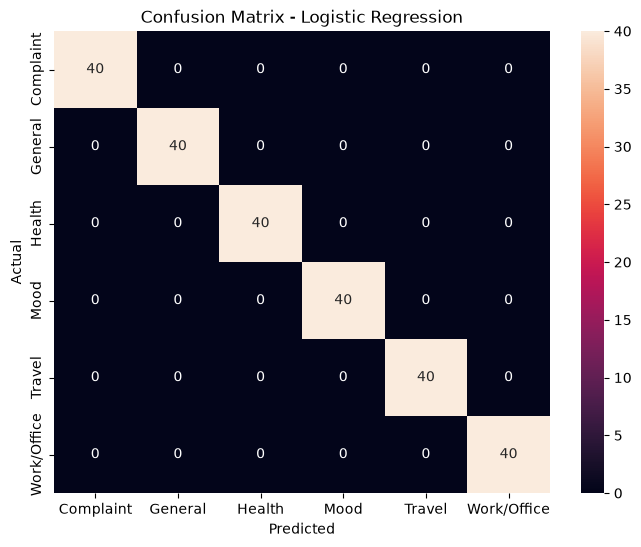

In [98]:
cm = confusion_matrix(y_test, y_pred_lr)

labels = sorted(y_test.unique())

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [99]:
new_sentences = [
    "I've been feeling sick since this morning",
    "Aaj mera bilkul mann nahi lag raha",
    "I might reach work a little late today",
    "Meri flight kal morning mein hai",
    "This application keeps showing an error",
    "Can you explain this to me?"
]

predictions = lr_pipeline.predict(new_sentences)
probabilities = lr_pipeline.predict_proba(new_sentences)

for text, prediction, probability in zip(
    new_sentences,
    predictions,
    probabilities
):
    confidence = np.max(probability)

    print(f"Text: {text}")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 50)

Text: I've been feeling sick since this morning
Prediction: Mood
Confidence: 0.4967
--------------------------------------------------
Text: Aaj mera bilkul mann nahi lag raha
Prediction: Mood
Confidence: 0.4263
--------------------------------------------------
Text: I might reach work a little late today
Prediction: Work/Office
Confidence: 0.4904
--------------------------------------------------
Text: Meri flight kal morning mein hai
Prediction: Travel
Confidence: 0.5381
--------------------------------------------------
Text: This application keeps showing an error
Prediction: Complaint
Confidence: 0.5372
--------------------------------------------------
Text: Can you explain this to me?
Prediction: General
Confidence: 0.7131
--------------------------------------------------


In [100]:
challenge_sentences = [
    # ---------------- HEALTH ----------------
    "I've been feeling unwell since I woke up.",
    "My body feels weak and I don't know why.",
    "I have been feeling sick since yesterday.",
    "Mujhe subah se weakness feel ho rahi hai.",
    "Aaj meri tabiyat bilkul theek nahi hai.",
    "Mere stomach mein subah se pain ho raha hai.",
    "I think I need to rest because I feel physically exhausted.",
    "Mujhe kal raat se headache ho raha hai.",
    "I am feeling dizzy after getting up.",
    
    # ---------------- MOOD ----------------
    "I've been feeling low for the past few days.",
    "I don't feel emotionally good today.",
    "Aaj mera mann kisi bhi kaam mein nahi lag raha.",
    "I am really happy about what happened today.",
    "Mera mood aaj kaafi acha hai.",
    "I feel frustrated with everything around me.",
    "Aaj main bahut stressed feel kar raha hoon.",
    "I have been feeling lonely lately.",
    
    # ---------------- WORK / OFFICE ----------------
    "I won't be able to get to work on time today.",
    "Meri meeting thodi der mein start hone wali hai.",
    "I need to finish this task before the deadline.",
    "Aaj mujhe office se jaldi nikalna padega.",
    "I am working from home today.",
    "Boss ne mujhe ek new task assign kiya hai.",
    "I may join the meeting a few minutes late.",
    "Mujhe kal office mein presentation deni hai.",
    "I have a lot of work to finish before lunch.",
    
    # ---------------- TRAVEL ----------------
    "My flight has been delayed by two hours.",
    "Mujhe kal subah Pune jaana hai.",
    "The train was cancelled because of the delay.",
    "Meri bus abhi tak nahi aayi hai.",
    "I need to book a cab to the airport.",
    "Hum weekend par Mumbai travel karne wale hain.",
    "My hotel reservation is for tomorrow night.",
    "The traffic is making me late for my journey.",
    
    # ---------------- COMPLAINT ----------------
    "The website keeps crashing whenever I try to log in.",
    "Mera internet baar baar disconnect ho raha hai.",
    "I am not happy with the service I received.",
    "Ye application open hi nahi ho raha hai.",
    "The payment was deducted but my order was not placed.",
    "Mujhe is service ke saath bahut problem aa rahi hai.",
    "The customer support team has not responded yet.",
    "This product stopped working after a few days.",
    
    # ---------------- GENERAL ----------------
    "Can you tell me how this process works?",
    "Mujhe iske baare mein thodi information chahiye.",
    "What time does the store open?",
    "Kya aap mujhe iska answer bata sakte ho?",
    "I would like to know more about this.",
    "Mujhe samajh nahi aa raha ki ye kaise karna hai.",
    "Can you explain this process in simple words?"
]

In [101]:
predictions = lr_pipeline.predict(challenge_sentences)
probabilities = lr_pipeline.predict_proba(challenge_sentences)

for text, prediction, probability in zip(
    challenge_sentences,
    predictions,
    probabilities
):
    confidence = np.max(probability)

    print(f"Text: {text}")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 70)

Text: I've been feeling unwell since I woke up.
Prediction: Health
Confidence: 0.4613
----------------------------------------------------------------------
Text: My body feels weak and I don't know why.
Prediction: General
Confidence: 0.2059
----------------------------------------------------------------------
Text: I have been feeling sick since yesterday.
Prediction: Health
Confidence: 0.5843
----------------------------------------------------------------------
Text: Mujhe subah se weakness feel ho rahi hai.
Prediction: Mood
Confidence: 0.8031
----------------------------------------------------------------------
Text: Aaj meri tabiyat bilkul theek nahi hai.
Prediction: Health
Confidence: 0.4832
----------------------------------------------------------------------
Text: Mere stomach mein subah se pain ho raha hai.
Prediction: Health
Confidence: 0.5328
----------------------------------------------------------------------
Text: I think I need to rest because I feel physically exha

In [102]:
challenge_results = pd.DataFrame({
    "text": challenge_sentences,
    "predicted_category": predictions,
    "confidence": probabilities.max(axis=1)
})

challenge_results

,text,predicted_category,confidence
0,I've been feeling unwell since I woke up.,Health,0.461253
1,My body feels weak and I don't know why.,General,0.205895
2,I have been feeling sick since yesterday.,Health,0.584349
3,Mujhe subah se weakness feel ho rahi hai.,Mood,0.803117
4,Aaj meri tabiyat bilkul theek nahi hai.,Health,0.483165
5,Mere stomach mein subah se pain ho raha hai.,Health,0.532772
6,I think I need to rest because I feel physical...,Work/Office,0.298329
7,Mujhe kal raat se headache ho raha hai.,Health,0.527764
8,I am feeling dizzy after getting up.,Mood,0.319946
9,I've been feeling low for the past few days.,Health,0.487674


In [103]:
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [104]:
final_pipeline.fit(
    df["clean_text"],
    df["category"]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['Complaint','General','Health','Mood','Travel','Work/Office']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [107]:
joblib.dump(
    final_pipeline,
    "../models/category_model.pkl"
)

['../models/category_model.pkl']

In [28]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True
    )),
    ("classifier", MultinomialNB())
])

In [29]:
nb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U11](6,)","['Complaint','General','Health','Mood','Travel','Work/Office']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [30]:
y_pred_nb = nb_pipeline.predict(X_test)

In [31]:
y_pred_nb = nb_pipeline.predict(X_test)

In [32]:
print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

   Complaint       1.00      1.00      1.00        40
     General       1.00      1.00      1.00        40
      Health       0.95      0.97      0.96        40
        Mood       0.97      0.95      0.96        40
      Travel       1.00      1.00      1.00        40
 Work/Office       1.00      1.00      1.00        40

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240



In [33]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True
    )),
    ("classifier", LinearSVC())
])

In [34]:
svm_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['Complaint','General','Health','Mood','Travel','Work/Office']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [35]:
y_pred_svm = svm_pipeline.predict(X_test)

In [36]:
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

   Complaint       1.00      1.00      1.00        40
     General       1.00      1.00      1.00        40
      Health       1.00      1.00      1.00        40
        Mood       1.00      1.00      1.00        40
      Travel       1.00      1.00      1.00        40
 Work/Office       1.00      1.00      1.00        40

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [37]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

In [38]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr
    )
)

results.append(
    evaluate_model(
        "Naive Bayes",
        y_test,
        y_pred_nb
    )
)

results.append(
    evaluate_model(
        "Linear SVM",
        y_test,
        y_pred_svm
    )
)

In [39]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0000,1.000000,1.0000,1.000000
1,Naive Bayes,0.9875,0.987596,0.9875,0.987498
2,Linear SVM,1.0000,1.000000,1.0000,1.000000


In [42]:
results_df = pd.DataFrame(results)

results_df
sample = ["Mujhe office late pahuchna hai"]

prediction = lr_pipeline.predict(sample)
probability = lr_pipeline.predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", probability)
confidence = np.max(probability)

print("Confidence:", confidence)


Prediction: ['Work/Office']
Probability: [[0.09235937 0.14967548 0.1611771  0.14791458 0.10870751 0.34016596]]
Confidence: 0.3401659581955692


In [59]:
# Naive Bayes - Manual Testing

nb_predictions = nb_pipeline.predict(challenge_sentences)
nb_probabilities = nb_pipeline.predict_proba(challenge_sentences)
nb_confidence = nb_probabilities.max(axis=1)

nb_manual_results = pd.DataFrame({
    "text": challenge_sentences,
    "predicted_category": nb_predictions,
    "confidence": nb_confidence
})

print("Naive Bayes - Manual Testing")
print("=" * 80)

for _, row in nb_manual_results.iterrows():
    print(f"Text: {row['text']}")
    print(f"Prediction: {row['predicted_category']}")
    print(f"Confidence: {row['confidence']:.4f}")
    print("-" * 80)

nb_manual_results

Naive Bayes - Manual Testing
Text: I've been feeling unwell since I woke up.
Prediction: Health
Confidence: 0.6354
--------------------------------------------------------------------------------
Text: My body feels weak and I don't know why.
Prediction: General
Confidence: 0.2497
--------------------------------------------------------------------------------
Text: I have been feeling sick since yesterday.
Prediction: Health
Confidence: 0.6394
--------------------------------------------------------------------------------
Text: Mujhe subah se weakness feel ho rahi hai.
Prediction: Mood
Confidence: 0.7965
--------------------------------------------------------------------------------
Text: Aaj meri tabiyat bilkul theek nahi hai.
Prediction: Health
Confidence: 0.6252
--------------------------------------------------------------------------------
Text: Mere stomach mein subah se pain ho raha hai.
Prediction: Health
Confidence: 0.6037
---------------------------------------------------

,text,predicted_category,confidence
0,I've been feeling unwell since I woke up.,Health,0.635406
1,My body feels weak and I don't know why.,General,0.249718
2,I have been feeling sick since yesterday.,Health,0.639384
3,Mujhe subah se weakness feel ho rahi hai.,Mood,0.796526
4,Aaj meri tabiyat bilkul theek nahi hai.,Health,0.625196
5,Mere stomach mein subah se pain ho raha hai.,Health,0.603749
6,I think I need to rest because I feel physical...,Work/Office,0.310123
7,Mujhe kal raat se headache ho raha hai.,Health,0.626306
8,I am feeling dizzy after getting up.,Health,0.338583
9,I've been feeling low for the past few days.,Health,0.719266


In [ ]:
expected_labels = [
    "Health",
    "Health",
    "Health",
    "Health",
    "Health",
    "Health",
    "Health",
    "Health",
    "Mood",
    # ...
]

In [60]:
hindi_words = {
    "mujhe", "mera", "meri", "mere",
    "hai", "hain", "ho", "raha", "rahi",
    "karna", "karni", "karo",
    "kaafi", "bahut", "aaj", "kal",
    "pichle", "liye", "mein", "se",
    "ko", "ka", "ki", "ke",
    "nahi", "nahi", "tha", "thi",
    "gaya", "gayi", "sakta", "sakti"
}

In [61]:
def detect_language(text):

    words = text.lower().split()

    hindi_count = sum(
        1 for word in words
        if word in hindi_words
    )

    if hindi_count >= 2:
        return "Hinglish"

    return "English"

In [62]:
def detect_language(text):

    text = text.lower()

    hindi_words = [
        "mujhe", "mera", "meri", "mere",
        "hai", "hain", "ho", "hoga",
        "raha", "rahi", "rahe",
        "karna", "karni", "karne",
        "nahi", "bahut", "kaafi",
        "aaj", "kal", "abhi",
        "mein", "se", "ko", "ka", "ki", "ke",
        "liye", "pichle"
    ]

    words = text.split()

    hindi_count = sum(
        word in hindi_words
        for word in words
    )

    if hindi_count >= 2:
        return "Hinglish"

    return "English"

In [63]:
test_sentences = [
    "I am not feeling well today.",
    "Mujhe aaj headache ho raha hai.",
    "I need to finish my work before the deadline.",
    "Mujhe office late pahuchna hai.",
    "My flight is tomorrow morning.",
    "Meri flight kal subah hai.",
    "Can you explain this process?",
    "Kya aap mujhe ye process samjha sakte ho?",
    "The website is showing an error.",
    "Website baar baar error dikha rahi hai.",
    "I am feeling very happy today.",
    "Aaj mera mood bahut accha hai."
]

for text in test_sentences:
    print(f"Text: {text}")
    print(f"Language: {detect_language(text)}")
    print("-" * 60)

Text: I am not feeling well today.
Language: English
------------------------------------------------------------
Text: Mujhe aaj headache ho raha hai.
Language: Hinglish
------------------------------------------------------------
Text: I need to finish my work before the deadline.
Language: English
------------------------------------------------------------
Text: Mujhe office late pahuchna hai.
Language: English
------------------------------------------------------------
Text: My flight is tomorrow morning.
Language: English
------------------------------------------------------------
Text: Meri flight kal subah hai.
Language: Hinglish
------------------------------------------------------------
Text: Can you explain this process?
Language: English
------------------------------------------------------------
Text: Kya aap mujhe ye process samjha sakte ho?
Language: English
------------------------------------------------------------
Text: The website is showing an error.
Language: 

In [64]:
import pandas as pd

df = pd.read_csv("../data/dataset.csv")

print(df.head())
print(df["language"].value_counts())

                                                text     category  language
0                         Bus bahut crowded thi aaj.       Travel  Hinglish
1  I need to hand over my tasks before I leave th...  Work/Office   English
2  Mere ilake ka traffic signal kharab hai hamesh...       Travel  Hinglish
3  Mujhe service ke baare mein ek general query h...      General  Hinglish
4   Meri request pe koi follow up nahi hua har baar.    Complaint  Hinglish
language
Hinglish    600
English     600
Name: count, dtype: int64


In [65]:
X = df["text"]
y = df["language"]

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 960
Testing: 240


In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(960, 2367)


In [68]:
from sklearn.linear_model import LogisticRegression

language_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

language_model.fit(X_train_tfidf, y_train)

print("Language model trained successfully!")

Language model trained successfully!


In [69]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = language_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

     English       1.00      1.00      1.00       120
    Hinglish       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [70]:
test_sentences = [
    "I am feeling very tired today.",
    "Mujhe aaj bahut thakan ho rahi hai.",
    "I need to attend the meeting at 10 AM.",
    "Mujhe 10 baje meeting attend karni hai.",
    "My flight is tomorrow morning.",
    "Meri flight kal subah hai.",
    "Can you explain how this works?",
    "Kya aap mujhe samjha sakte ho ki ye kaise kaam karta hai?",
    "The application is showing an error.",
    "Application mein baar baar error aa raha hai."
]

X_manual = vectorizer.transform(test_sentences)

predictions = language_model.predict(X_manual)
probabilities = language_model.predict_proba(X_manual)

for text, prediction, probability in zip(
    test_sentences,
    predictions,
    probabilities
):
    confidence = probability.max()

    print("Text:", text)
    print("Language:", prediction)
    print(f"Confidence: {confidence:.4f}")
    print("-" * 70)

Text: I am feeling very tired today.
Language: English
Confidence: 0.8671
----------------------------------------------------------------------
Text: Mujhe aaj bahut thakan ho rahi hai.
Language: Hinglish
Confidence: 0.9757
----------------------------------------------------------------------
Text: I need to attend the meeting at 10 AM.
Language: English
Confidence: 0.8938
----------------------------------------------------------------------
Text: Mujhe 10 baje meeting attend karni hai.
Language: Hinglish
Confidence: 0.7619
----------------------------------------------------------------------
Text: My flight is tomorrow morning.
Language: English
Confidence: 0.8361
----------------------------------------------------------------------
Text: Meri flight kal subah hai.
Language: Hinglish
Confidence: 0.8812
----------------------------------------------------------------------
Text: Can you explain how this works?
Language: English
Confidence: 0.8540
----------------------------------

In [71]:
test_sentences = [
    # English - 1
    "I woke up with a terrible headache this morning.",

    # Hinglish - 2
    "Mujhe subah uthne ke baad se headache ho raha hai.",

    # English - 3
    "I have been feeling unusually weak since yesterday.",

    # Hinglish - 4
    "Aaj se meri tabiyat thodi ajeeb lag rahi hai.",

    # English - 5
    "My throat hurts whenever I try to swallow.",

    # Hinglish - 6
    "Mera gala kal raat se dukh raha hai.",

    # English - 7
    "I have been in a really positive mood today.",

    # Hinglish - 8
    "Aaj main kaafi khush feel kar raha hoon.",

    # English - 9
    "I can't concentrate because I have been feeling stressed.",

    # Hinglish - 10
    "Mera dimaag bahut stressed feel kar raha hai aajkal.",

    # English - 11
    "I need to send the project report before the meeting.",

    # Hinglish - 12
    "Mujhe meeting se pehle project report bhejni hai.",

    # English - 13
    "My manager wants me to finish this task today.",

    # Hinglish - 14
    "Manager ne bola hai ki ye task aaj complete karna hai.",

    # English - 15
    "I will be working remotely tomorrow.",

    # Hinglish - 16
    "Kal main ghar se kaam karne wala hoon.",

    # English - 17
    "I have to attend an important client call this afternoon.",

    # Hinglish - 18
    "Aaj afternoon mein meri important client call hai.",

    # English - 19
    "My flight leaves early tomorrow morning.",

    # Hinglish - 20
    "Meri flight kal subah bahut jaldi hai.",

    # English - 21
    "We are planning to visit Goa during the holidays.",

    # Hinglish - 22
    "Hum holidays mein Goa jaane ka plan bana rahe hain.",

    # English - 23
    "The train was cancelled without any prior notice.",

    # Hinglish - 24
    "Meri train bina bataye cancel kar di gayi.",

    # English - 25
    "I need to find a hotel close to the airport.",

    # Hinglish - 26
    "Mujhe airport ke paas ek hotel dhoondhna hai.",

    # English - 27
    "The delivery arrived two days later than expected.",

    # Hinglish - 28
    "Mera order expected time se do din late aaya.",

    # English - 29
    "I was charged for the same item twice.",

    # Hinglish - 30
    "Mere same order ke liye do baar payment cut ho gayi.",

    # English - 31
    "The customer service team has not replied to me yet.",

    # Hinglish - 32
    "Customer support ne abhi tak mujhe reply nahi kiya.",

    # English - 33
    "The application stops responding whenever I open it.",

    # Hinglish - 34
    "App open karte hi baar baar hang ho jaata hai.",

    # English - 35
    "Could you tell me how I can update my account details?",

    # Hinglish - 36
    "Kya aap bata sakte ho ki account details kaise update karni hain?",

    # English - 37
    "I would like some clarification about this process.",

    # Hinglish - 38
    "Mujhe is process ke baare mein thodi clarity chahiye.",

    # English - 39
    "Can you explain what I need to do next?",

    # Hinglish - 40
    "Ab mujhe next kya karna hai, bata sakte ho?",

    # English - 41
    "I am not sure why I have been feeling so lonely lately.",

    # Hinglish - 42
    "Pata nahi kyun, main aajkal bahut lonely feel kar raha hoon.",

    # English - 43
    "There is something wrong with my internet connection.",

    # Hinglish - 44
    "Mera internet connection baar baar disconnect ho raha hai.",

    # English - 45
    "I might arrive at the office a little later than usual.",

    # Hinglish - 46
    "Aaj office pahuchne mein thoda late ho sakta hai.",

    # English - 47
    "I am excited about the trip we have planned.",

    # Hinglish - 48
    "Jo trip humne plan ki hai usko lekar main bahut excited hoon.",

    # English - 49
    "I need more information before I make a decision.",

    # Hinglish - 50
    "Decision lene se pehle mujhe thodi aur information chahiye."
]

In [72]:
X_manual = vectorizer.transform(test_sentences)

predictions = language_model.predict(X_manual)
probabilities = language_model.predict_proba(X_manual)

for i, (text, prediction, probability) in enumerate(
    zip(test_sentences, predictions, probabilities), 1
):
    confidence = probability.max()

    print(f"{i}. Text: {text}")
    print(f"   Prediction: {prediction}")
    print(f"   Confidence: {confidence:.4f}")
    print("-" * 80)

1. Text: I woke up with a terrible headache this morning.
   Prediction: English
   Confidence: 0.8401
--------------------------------------------------------------------------------
2. Text: Mujhe subah uthne ke baad se headache ho raha hai.
   Prediction: Hinglish
   Confidence: 0.9774
--------------------------------------------------------------------------------
3. Text: I have been feeling unusually weak since yesterday.
   Prediction: English
   Confidence: 0.9387
--------------------------------------------------------------------------------
4. Text: Aaj se meri tabiyat thodi ajeeb lag rahi hai.
   Prediction: Hinglish
   Confidence: 0.8945
--------------------------------------------------------------------------------
5. Text: My throat hurts whenever I try to swallow.
   Prediction: English
   Confidence: 0.8150
--------------------------------------------------------------------------------
6. Text: Mera gala kal raat se dukh raha hai.
   Prediction: Hinglish
   Confidenc

In [77]:
vectorizer = TfidfVectorizer(ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

language_model = LogisticRegression(max_iter=1000)
language_model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [81]:
text = "do you want to eat food"

# Transform using the SAME vectorizer used during training
text_tfidf = vectorizer.transform([text])

# Predict
prediction = language_model.predict(text_tfidf)[0]

# Confidence
confidence = max(language_model.predict_proba(text_tfidf)[0])

print("Text:", text)
print("Predicted Language:", prediction)
print("Confidence:", round(confidence, 4))

Text: do you want to eat food
Predicted Language: English
Confidence: 0.7922


In [79]:
%whos

Variable                Type                  Data/Info
-------------------------------------------------------
LinearSVC               type                  <class 'sklearn.svm._classes.LinearSVC'>
LogisticRegression      type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
MultinomialNB           ABCMeta               <class 'sklearn.naive_bayes.MultinomialNB'>
Pipeline                ABCMeta               <class 'sklearn.pipeline.Pipeline'>
TfidfVectorizer         type                  <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
X                       Series                Shape: (1200,)
X_manual                csr_matrix            <Compressed Sparse Row sp<...>2115)	0.32457932079479623
X_test                  Series                Shape: (240,)
X_test_tfidf            csr_matrix            <Compressed Sparse Row sp<...>2259)	0.25641472307943136
X_train                 Series                Shape: (960,)
X_train_tfidf           csr_matrix      

In [109]:
# ==========================================
# TRAIN LANGUAGE MODEL ON ENTIRE DATASET
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib
import os

# Full dataset
X_full = df["text"].astype(str)
y_full = df["language"]

# Create a NEW TF-IDF vectorizer
language_vectorizer_full = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True
)

# Fit TF-IDF on the ENTIRE dataset
X_full_tfidf = language_vectorizer_full.fit_transform(X_full)

# Create a NEW Logistic Regression model
language_model_full = LogisticRegression(
    max_iter=1000
)

# Train on 100% of the data
language_model_full.fit(X_full_tfidf, y_full)

print("Language model trained successfully on entire dataset.")
print("Total samples:", len(X_full))
print("Features:", X_full_tfidf.shape[1])

Language model trained successfully on entire dataset.
Total samples: 1200
Features: 2483


In [110]:
# ==========================================
# SAVE FINAL LANGUAGE MODEL
# ==========================================

os.makedirs("../model", exist_ok=True)

joblib.dump(
    language_vectorizer_full,
    "../models/language_vectorizer.pkl"
)

joblib.dump(
    language_model_full,
    "../models/language_model.pkl"
)

print("\nModel saved successfully!")
print("../model/language_vectorizer.pkl")
print("../model/language_model.pkl")


Model saved successfully!
../model/language_vectorizer.pkl
../model/language_model.pkl


In [111]:
# ==========================================
# SAVE FINAL LANGUAGE MODEL
# ==========================================

os.makedirs("../models", exist_ok=True)

joblib.dump(
    language_vectorizer_full,
    "../models/language_vectorizer.pkl"
)

joblib.dump(
    language_model_full,
    "../models/language_model.pkl"
)

print("\nModels saved successfully!")
print("../models/language_vectorizer.pkl")
print("../models/language_model.pkl")


Models saved successfully!
../models/language_vectorizer.pkl
../models/language_model.pkl


In [113]:
# ==============================
# CATEGORY MODEL
# ==============================

X_category = df["text"].astype(str)
y_category = df["category"]

# TF-IDF
category_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_category_tfidf = category_vectorizer.fit_transform(X_category)

# Logistic Regression
category_model = LogisticRegression(
    max_iter=1000
)

category_model.fit(X_category_tfidf, y_category)

# Save
joblib.dump(
    category_vectorizer,
    "../models/category_vectorizer.pkl"
)

joblib.dump(
    category_model,
    "../models/category_model.pkl"
)

print("Category model trained on full dataset.")
print("Category vectorizer saved.")
print("Category model saved.")

Category model trained on full dataset.
Category vectorizer saved.
Category model saved.
